In [1]:
#Imports : 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

df.info()

df.shape

df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [6]:
df.isnull().sum().sum()
df.duplicated().sum()

np.int64(0)

In [7]:
for col in df.columns:
    print(col, df[col].nunique())

customerID 7043
gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 73
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1585
TotalCharges 6531
Churn 2


In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

df["TotalCharges"] = df["TotalCharges"].astype(float)

df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

C:\Users\hada\AppData\Local\Temp\ipykernel_8812\400153224.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


In [10]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [11]:
#cheak categorical columns and their unique values
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print("-"*30)

gender
['Female' 'Male']
------------------------------
Partner
['Yes' 'No']
------------------------------
Dependents
['No' 'Yes']
------------------------------
PhoneService
['No' 'Yes']
------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
------------------------------
DeviceProtection
['No' 'Yes' 'No internet service']
------------------------------
TechSupport
['No' 'Yes' 'No internet service']
------------------------------
StreamingTV
['No' 'Yes' 'No internet service']
------------------------------
StreamingMovies
['No' 'Yes' 'No internet service']
------------------------------
Contract
['Month-to-month' 'One year' 'Two year']
------------------------------
PaperlessBilling
['Yes' 'No']
------------------------------
Paymen

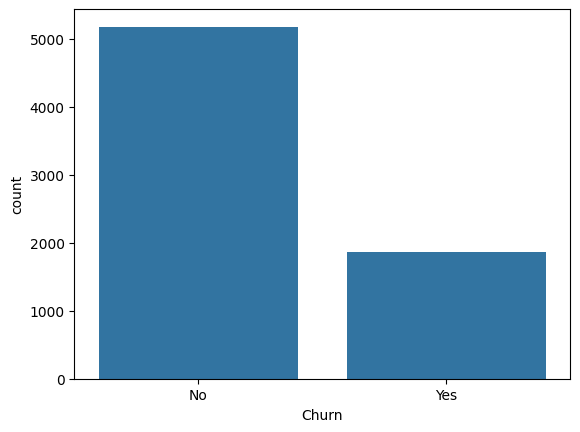

In [12]:
df["Churn"].value_counts()

sns.countplot(x="Churn", data=df)
plt.show()

<Axes: xlabel='gender', ylabel='count'>

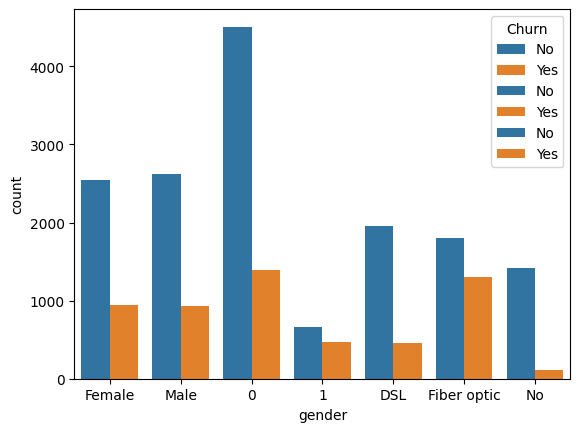

In [13]:
sns.countplot(x="gender", hue="Churn", data=df)
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
sns.countplot(x="InternetService", hue="Churn", data=df)


<Axes: xlabel='Contract', ylabel='count'>

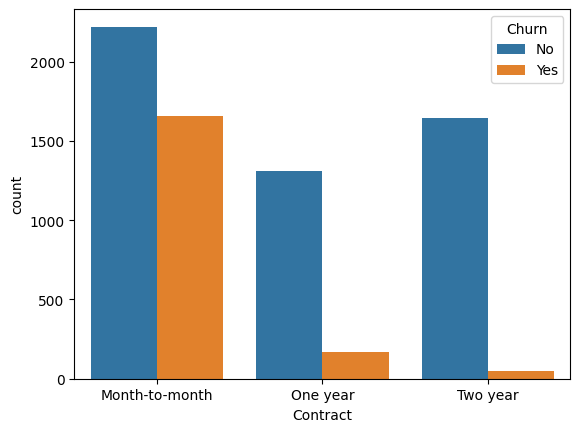

In [14]:
#sns.countplot(x="PaymentMethod", hue="Churn", data=df)
sns.countplot(x="Contract", hue="Churn", data=df)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

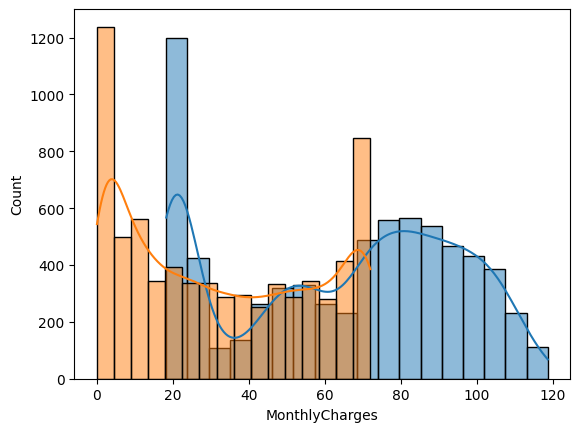

In [15]:
sns.histplot(df["MonthlyCharges"], kde=True)
sns.histplot(df["tenure"], kde=True)
df["Churn"].value_counts(normalize=True)*100

In [16]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0}) # Label Encoding
df = pd.get_dummies(df, drop_first = True)


In [17]:
X = df.drop('Churn', axis = 1) # Independent Feature
y = df['Churn'] # Dependent Feature
# Train_Test_Split : 
X_train,X_test,y_train,y_test=train_test_split(X,
y,
test_size=0.2,
random_state=42
)

In [18]:
# Scaling :
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
# Training Time Measurement : 
import time

start_train = time.time()

clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_train, y_train)

end_train = time.time()
train_time = end_train - start_train

print(f"\nTraining Time: {train_time:.4f} seconds")


Training Time: 0.0444 seconds


In [20]:
lr=LogisticRegression()

lr.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier() 

rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
pred_lr=lr.predict(X_test)

pred_dt=dt.predict(X_test)

pred_rf=rf.predict(X_test)
# Cross Validation :
cv_scores = cross_val_score(clf, X_train, y_train, cv = 5)
print(cv_scores)
print(cv_scores.mean())

[0.81011535 0.80922804 0.79769299 0.78881988 0.80373002]
0.8019172546615371


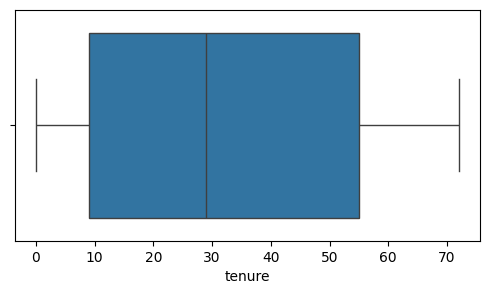

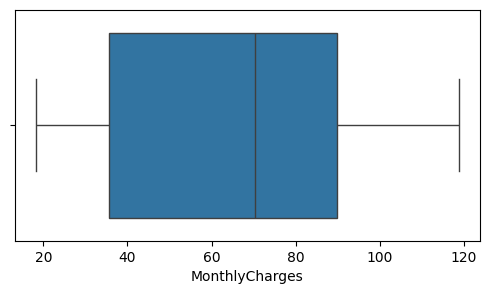

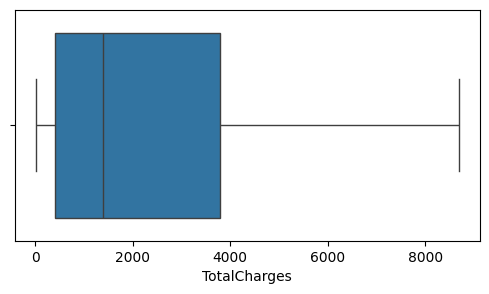

In [24]:
num = ['tenure','MonthlyCharges','TotalCharges']

for col in num:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.show()

<Axes: xlabel='Importance', ylabel='Feature'>

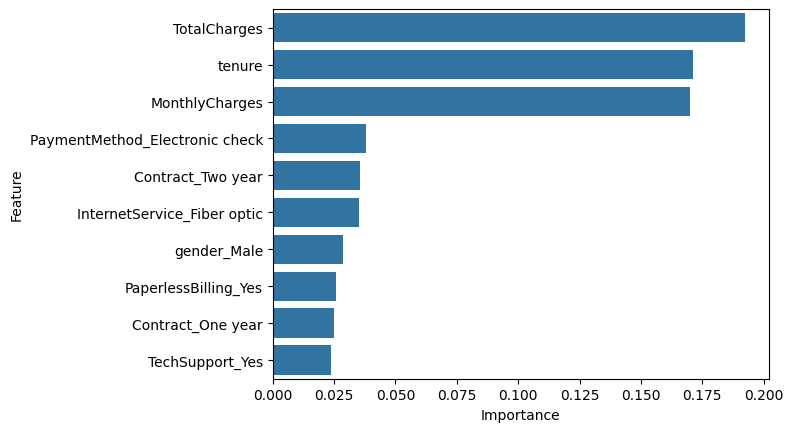

In [25]:
#Feature Importance :
importance=rf.feature_importances_

features=df.drop("Churn",axis=1).columns

imp=pd.DataFrame({
"Feature":features,
"Importance":importance
})

imp=imp.sort_values(by="Importance",ascending=False)

sns.barplot(data=imp.head(10),x="Importance",y="Feature")

In [26]:
# Failure Case Analysis : 
from sklearn.linear_model import LogisticRegression

misclassified = X_test[y_test != y_pred]
print(f"\nNumber of Misclassified Samples: {len(misclassified)}")

NameError: name 'y_pred' is not defined

In [ ]:
accu = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
ra = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accu:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC_AUC: {ra:.4f}")
print("\n")
print("Confusion Matrix:\n", cm)

Accuracy: 0.8197
Precision: 0.6831
Recall: 0.5952
F1 Score: 0.6361
ROC_AUC: 0.8620


Confusion Matrix:
 [[933 103]
 [151 222]]


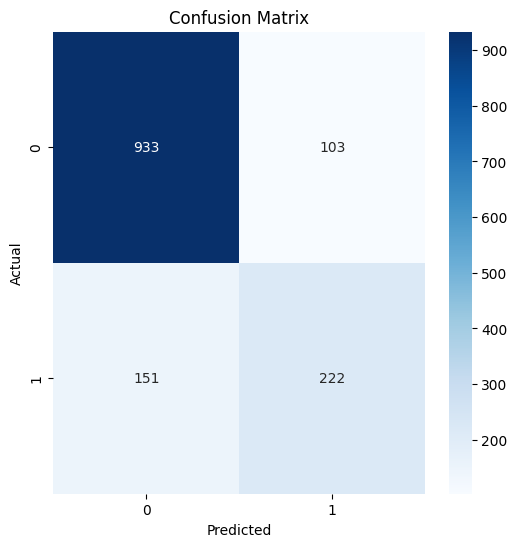

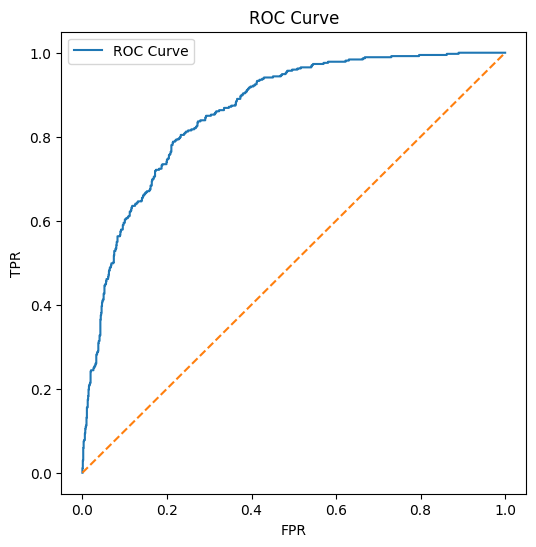

In [ ]:
# Visualization : 

plt.figure(figsize = (6,6))
sns.heatmap(cm, annot = True, fmt = "d" , cmap = "Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label = "ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")

plt.legend()
plt.show()

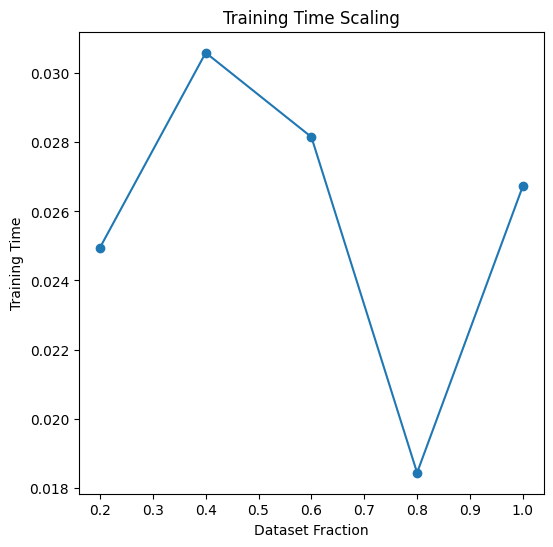

In [ ]:
# Scaling Experiment (Dataset Size vs Train Time) : 

sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
times = []

for s in sizes:
    X_sub = X_train[:int(len(X_train) * s)]
    y_sub = y_train[:int(len(y_train) * s)]

    start = time.time()
    LogisticRegression(max_iter=1000).fit(X_sub, y_sub)
    times.append(time.time() - start)

plt.figure(figsize=(6, 6))
plt.plot(sizes, times, marker='o')
plt.xlabel("Dataset Fraction")
plt.ylabel("Training Time")
plt.title("Training Time Scaling")
plt.show()